In [20]:
import pandas as pd
import numpy as np
import re
import nltk

In [21]:
dataset = pd.read_json('../dataset/Kindle_Store_5.json', lines=True)

In [22]:
dataset

,overall,verified,reviewTime,reviewerID,asin,style,reviewerName,reviewText,summary,unixReviewTime,vote,image
0,4,True,"07 3, 2014",A2LSKD2H9U8N0J,B000FA5KK0,{'Format:': ' Kindle Edition'},sandra sue marsolek,"pretty good story, a little exaggerated, but I...",pretty good story,1404345600,NaN,NaN
1,5,True,"05 26, 2014",A2QP13XTJND1QS,B000FA5KK0,{'Format:': ' Kindle Edition'},Tpl,"If you've read other max brand westerns, you k...",A very good book,1401062400,NaN,NaN
2,5,True,"09 16, 2016",A8WQ7MAG3HFOZ,B000FA5KK0,{'Format:': ' Kindle Edition'},Alverne F. Anderson,"Love Max, always a fun twist",Five Stars,1473984000,NaN,NaN
3,5,True,"03 3, 2016",A1E0MODSRYP7O,B000FA5KK0,{'Format:': ' Kindle Edition'},Jeff,"As usual for him, a good book",a good,1456963200,NaN,NaN
4,5,True,"09 10, 2015",AYUTCGVSM1H7T,B000FA5KK0,{'Format:': ' Kindle Edition'},DEHS - EddyRapcon,MB is one of the original western writers and ...,A Western,1441843200,2,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2222978,3,False,"07 16, 2016",A3Q6HJYRJX87Z9,B01HJENY3Y,{'Format:': ' Kindle Edition'},Tokea,Ok book but some parts just didn't add up I fe...,Cool book,1468627200,NaN,NaN
2222979,5,False,"07 12, 2016",A2O7HQNKCMOMUP,B01HJENY3Y,{'Format:': ' Kindle Edition'},Angela Burnett,Kia I loved this book. I am so glad that Sky ...,Crazy Read,1468281600,NaN,NaN
2222980,5,False,"07 1, 2016",A38NOWP7LQI8CM,B01HJENY3Y,{'Format:': ' Kindle Edition'},Treka22,This picks up where part one left off. Secret ...,Loved it,1467331200,NaN,NaN
2222981,5,False,"07 1, 2016",A1H9WGEEKVK0FM,B01HJENY3Y,{'Format:': ' Kindle Edition'},Adrienne Jeremiah,What a beautiful ending to such a twisted begi...,Beautiful ending,1467331200,NaN,NaN


In [32]:
dataset = dataset[dataset["reviewText"].str.len() <= 200]

In [33]:
dataset

,reviewText,overall
1,"If you've read other max brand westerns, you k...",5
2,"Love Max, always a fun twist",5
3,"As usual for him, a good book",5
5,great book,5
7,ALMOST BEEN TOO LONG SINCE I READ IT. GOOD REA...,4
...,...,...
2222970,(7 year old's review)\n\nThey took a long time...,5
2222973,So much fun! Very cute and well done. Pirates ...,5
2222975,If you haven't noticed I love Kia Meches writi...,5
2222976,"I liked Secret. Sky,King,Parrish. I didn't lik...",5


In [ ]:
unused_columns = [
    "verified",
    "reviewTime",
    "reviewerID",
    "asin",
    "style",
    "reviewerName",
    "summary",
    "unixReviewTime",
    "vote",
    "image"
]
dataset.drop(columns=unused_columns, inplace=True)

In [ ]:
dataset

In [ ]:
dataset = dataset[[col if col != "overall" and col != "reviewText" else "overall" if col == "reviewText" else "reviewText" for col in dataset.columns]]

In [30]:
import matplotlib.pyplot as plt

C:\Users\lsaid\AppData\Local\Temp\ipykernel_22308\3451481992.py:2: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(dataset['overall']).plot.bar(title="Rating distribution in dataset")


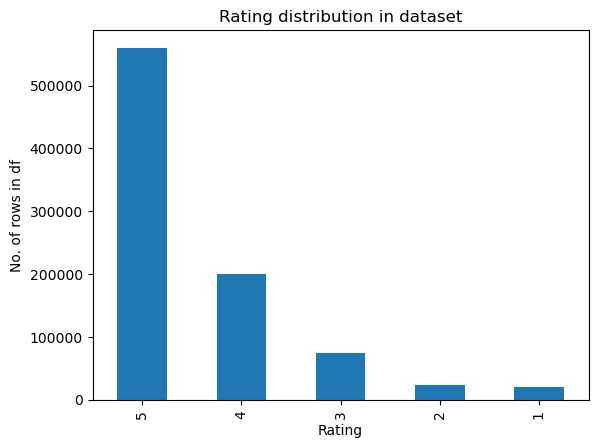

In [31]:
plt.figure()
pd.value_counts(dataset['overall']).plot.bar(title="Rating distribution in dataset")
plt.xlabel("Rating")
plt.ylabel("No. of rows in df")
plt.show()

In [11]:
dataset

,reviewText,overall
0,"pretty good story, a little exaggerated, but I...",4
1,"If you've read other max brand westerns, you k...",5
2,"Love Max, always a fun twist",5
3,"As usual for him, a good book",5
4,MB is one of the original western writers and ...,5
...,...,...
2222978,Ok book but some parts just didn't add up I fe...,3
2222979,Kia I loved this book. I am so glad that Sky ...,5
2222980,This picks up where part one left off. Secret ...,5
2222981,What a beautiful ending to such a twisted begi...,5


In [35]:
dataset.isna().sum()

reviewText    0
overall       0
dtype: int64

In [36]:
dataset[dataset["reviewText"].isna()]

,reviewText,overall


In [14]:
dataset.dropna(inplace=True)

C:\Users\lsaid\AppData\Local\Temp\ipykernel_22308\2639109627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.dropna(inplace=True)


In [15]:
dataset[dataset["reviewText"].isna()]

,reviewText,overall


In [37]:
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import remove_stopwords

In [ ]:
dataset["reviewText"] = [simple_preprocess(review, deacc=True) for review in dataset["reviewText"]]

In [41]:
dataset["reviewText"].head()

1    [if, you, ve, read, other, max, brand, western...
2                      [love, max, always, fun, twist]
3                    [as, usual, for, him, good, book]
5                                        [great, book]
7    [almost, been, too, long, since, read, it, goo...
Name: reviewText, dtype: object

In [40]:
from gensim.parsing.porter import PorterStemmer
ps = PorterStemmer()

In [42]:
dataset["reviewText"] = [[ps.stem(word) for word in review_array] for review_array in dataset["reviewText"]]
dataset["reviewText"].head()

1    [if, you, ve, read, other, max, brand, western...
2                       [love, max, alwai, fun, twist]
3                    [as, usual, for, him, good, book]
5                                        [great, book]
7    [almost, been, too, long, sinc, read, it, good...
Name: reviewText, dtype: object

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset["reviewText"], dataset["overall"], test_size=0.33, random_state=50)

In [44]:
X_train

965821     [sexi, read, am, sucker, for, the, bad, boi, w...
931494     [love, be, abl, to, read, all, the, stori, fro...
44088      [like, thi, stori, but, aggrav, me, at, how, s...
2178477    [didn, like, the, wai, it, end, wa, sad, in, a...
312385     [shorter, than, like, but, full, of, intrigu, ...
                                 ...                        
778077                                          [good, seri]
1078248    [cute, short, stori, about, second, chanc, at,...
1720070    [like, the, book, kept, my, interest, didn, gu...
569676     [realli, like, western, thei, aren, on, tv, an...
237693     [realli, enjoi, the, back, round, on, channi, ...
Name: reviewText, Length: 589437, dtype: object

In [48]:
train_set = pd.concat([X_train, y_train], axis=1)
test_set = pd.concat([X_test, y_test], axis=1)

In [49]:
train_set

,reviewText,overall
965821,"[sexi, read, am, sucker, for, the, bad, boi, w...",4
931494,"[love, be, abl, to, read, all, the, stori, fro...",5
44088,"[like, thi, stori, but, aggrav, me, at, how, s...",4
2178477,"[didn, like, the, wai, it, end, wa, sad, in, a...",3
312385,"[shorter, than, like, but, full, of, intrigu, ...",4
...,...,...
778077,"[good, seri]",5
1078248,"[cute, short, stori, about, second, chanc, at,...",4
1720070,"[like, the, book, kept, my, interest, didn, gu...",4
569676,"[realli, like, western, thei, aren, on, tv, an...",5


In [50]:
test_set

,reviewText,overall
691418,"[enjoi, thi, seri, have, read, coupl, of, her,...",5
24922,"[excel, for, sure, definit, made, me, feel, as...",5
1772524,"[fast, move, syfi, thriller, that, keep, you, ...",5
1788759,"[edg, of, your, set, sy, fy]",4
965598,"[wow, is, all, can, sai, would, love, to, find...",5
...,...,...
1696045,"[after, have, read, book, in, thi, seri, wasn,...",5
1224819,[ok],3
405007,"[davina, is, gone, mourn, her, along, with, br...",5
1817036,[okai],5


In [52]:
train_set.to_csv('../input/train_set.csv', sep="\t", index=False)
test_set.to_csv('../input/test_set.csv', sep="\t", index=False)